# Analítica de Rendimiento despachos - Machine Learning

- **Autor:** Luis Miguel Marín Cadavid
- **Fecha:** 15 Julio 2026

---

## Descripción Fase 2

Este notebook optimiza la operación en bodega mediante **técnicas de Machine Learning**, abordando tres áreas principales:

| Área | Técnica | Objetivo |
|------|---------|----------|
| **Predicción de tiempos** | Random Forest / XGBoost | Estimar tiempo de preparación por ruta |
| **Segmentación de rutas** | K-Means Clustering | Identificar patrones operativos |
| **Simulación de jornadas** | Modelo predictivo + reglas de negocio | Planificar escenarios operativos |

---

## Objetivos Estratégicos

1. **Predecir** `tiempo_preparacion_minutos` con error < 5 minutos
2. **Identificar** rutas "flash" (velocidad > 5,000 prod/h) para optimización
3. **Segmentar** rutas en perfiles operativos (Estrella/Normales/Pesadas)
4. **Simular** jornadas para mejorar asignación de personal

---

## Estructura del Notebook <a id='estructura'></a>

1. **Configuración** - Importación de librerías [Configuración](#configuracion)
2. **Carga de Datos** - Carga de datos limpios **Fase 1** [Carga de Datos](#cargadatos)
3. **Feature Engineering** - Creación de variables predictivas [Features Engineering](#feature)
4. **División Train/Test** - División de registros para aprender (80%) y demostrar (20%) [División Train/Test](#traintest)
5. **Entrenamiento de Modelos** - Random Forest y XGBoost [Modelado](#modelado)
6. **Evaluación y comparación** Métricas MAE, RMSE, R², MAPE [Evaluación y comparación](#evaluacion)
7. **Feature Importance** Factor más influyente para el tiempo de despacho [Feature Importance](#importance)
8. **Clustering de Rutas** - Segmentación de rutas [Clustering de Rutas](#clustering)
9. **Simulación** - Herramienta de planeación [Simulación](#simulacion)
10. **Persistencia de Modelos** - Guardado de artefactos [Persistencia](#persistencia)
11. **Conclusiones** - Hallazgos y recomendaciones [Conclusiones](#conclusiones)

## 1. Configuración <a id='configuracion'></a>
[Estructura](#estructura)

Se importan librerías necesarias para el análisis, modelado y visualización.

In [1]:
# Importamos librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score
)

# XGBoost
import xgboost as xgb

# Configuración de Visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Guardar el modelo
import joblib
import os

# Se importan desde src
import sys
sys.path.append('..')

from src.data_loader import CargadorDatos
from src.optimization import optimizar_asignacion, _asignacion_secuencial
from src.models import ModeloPrediccionTiempo, ClusteringRutas

print("Se importaron librerías correctamente")

Se importaron librerías correctamente


## 2. Carga de Datos <a id='cargadatos'></a>
[Estructura](#estructura)

Se cargan los datos limpios generados en la Fase 1 y se realiza una exploración inicial.

In [2]:
# Carga de datos limpios

# Se cargan los datos limpios generados en la Fase 1
df_clean = pd.read_csv('../data/processed/despachos_clean.csv')
df_clean['fecha'] = pd.to_datetime(df_clean['fecha'])

print(f"Dataset cargado: {df_clean.shape[0]} registros, {df_clean.shape[1]} columnas")
print(f"Rango de fechas: {df_clean['fecha'].min()} a {df_clean['fecha'].max()}")
print(f"Rutas únicas: {df_clean['id_ruta'].nunique()}")

Dataset cargado: 863 registros, 20 columnas
Rango de fechas: 2026-05-26 00:00:00 a 2026-08-08 00:00:00
Rutas únicas: 185


## 3. Feature Engineering <a id='feature'></a>
[Estructura](#estructura)


Se transforman los datos crudos en características que alimentarán los modelos predictivos.

### Variables creadas:

| Variable | Descripción |
|----------|-------------|
| `dia_semana` | Día de la semana (0=Lunes) |
| `es_jueves` | Flag para jueves |
| `es_lunes_o_viernes` | Flag para lunes/viernes |
| `velocidad_historica_ruta` | Velocidad promedio histórica |
| `frecuencia_ruta` | Número de veces que aparece |
| `es_ruta_flash` | Velocidad > 5,000 prod/h |

### Decisiones de Diseño:

- **Umbral flash:** 5,000 prod/h (captura ~1.2% de los datos)
- **Transformación logarítmica:** Aplicada a `cant_productos` y `valor_ruta` para reducir asimetría
- **Imputación:** Se realiza después del train/test split para evitar Data Leakage


In [3]:
# Features temporales (datos que recibe el modelo para predecir resultados)
df_clean['dia_semana'] = df_clean['fecha'].dt.dayofweek  # 0=Lunes, 6=Domingo
print("Feature temporal: dia_semana")

# Flags operativos basados en EDA
df_clean['es_jueves'] = (df_clean['dia_semana'] == 3).astype(int)
df_clean['es_lunes_o_viernes'] = (df_clean['dia_semana'].isin([0, 4])).astype(int)
print("Flags operativos: es_jueves, es_lunes_o_viernes")

# Features de ruta (agregaciones históricas)
ruta_stats = df_clean.groupby('id_ruta').agg(
    velocidad_historica_ruta=('velocidad_despacho', 'mean'),
    frecuencia_ruta=('id_ruta', 'count')
).reset_index()

# Identificar rutas flash (velocidad > 5,000 prod/h)
ruta_stats['es_ruta_flash'] = (ruta_stats['velocidad_historica_ruta'] > 5000).astype(int)
print("Features de ruta: velocidad_historica_ruta, frecuencia_ruta, es_ruta_flash")

# Merge con dataset principal
df_model = df_clean.merge(ruta_stats, on='id_ruta', how='left')

# Aplicar transformacion logaritmica a variables asimetricas
df_model['cant_productos_log'] = np.log1p(df_model['cant_productos'])
df_model['valor_ruta_log'] = np.log1p(df_model['valor_ruta'])

print("Transformacion logaritmica aplicada a: cant_productos, valor_ruta")

# Seleccion de features y target
feature_cols = [
    'cant_productos_log',      
    'valor_ruta_log',          
    'dia_semana',
    'es_jueves',
    'es_lunes_o_viernes',
    'velocidad_historica_ruta',
    'frecuencia_ruta',
    'es_ruta_flash'
]

target_col = 'tiempo_preparacion_minutos'

# Dataset final
df_features = df_model[feature_cols + [target_col, 'id_ruta']].copy()

# Validaciones post-feature engineering
print("\nVALIDACIONES\n")

nulos = df_features[feature_cols + [target_col]].isnull().sum()
if nulos.sum() > 0:
    print("Valores nulos detectados:")
    print(nulos[nulos > 0])
    print("\nNOTA: La imputacion se realizara DESPUES del train/test split")
    print("      usando exclusivamente la media del conjunto de entrenamiento")
    print("      para evitar Data Leakage.")
else:
    print("Sin valores nulos")

flash_count = df_features['es_ruta_flash'].sum()
print(f"Rutas flash: {flash_count} ({flash_count/len(df_features)*100:.1f}%)")
print(f"Features creadas: {len(feature_cols)}")
print(f"Dataset final: {df_features.shape[0]:,} registros, {df_features.shape[1]} columnas")

print("\nMuestra de datos:")
display(df_features.head(5))

print("\nEstadisticas de features (con transformacion logaritmica):")
display(df_features[feature_cols].describe())

Feature temporal: dia_semana
Flags operativos: es_jueves, es_lunes_o_viernes
Features de ruta: velocidad_historica_ruta, frecuencia_ruta, es_ruta_flash
Transformacion logaritmica aplicada a: cant_productos, valor_ruta

VALIDACIONES

Sin valores nulos
Rutas flash: 16 (1.9%)
Features creadas: 8
Dataset final: 863 registros, 10 columnas

Muestra de datos:


,cant_productos_log,valor_ruta_log,dia_semana,es_jueves,es_lunes_o_viernes,velocidad_historica_ruta,frecuencia_ruta,es_ruta_flash,tiempo_preparacion_minutos,id_ruta
0,3.637586,12.214304,1,0,0,683.143692,4,0,3.416667,9375
1,4.615121,12.953118,1,0,0,924.259213,4,0,6.316667,9378
2,3.891820,12.177390,1,0,0,652.539827,2,0,5.150000,9381
3,2.079442,10.996216,1,0,0,316.964607,6,0,1.866667,9383
4,4.969813,13.772135,1,0,0,946.416627,8,0,18.366667,7603



Estadisticas de features (con transformacion logaritmica):


,cant_productos_log,valor_ruta_log,dia_semana,es_jueves,es_lunes_o_viernes,velocidad_historica_ruta,frecuencia_ruta,es_ruta_flash
count,863.000000,863.000000,863.000000,863.000000,863.000000,863.000000,863.000000,863.000000
mean,5.619638,14.024120,2.690614,0.164542,0.283893,1777.754566,6.740440,0.018540
std,1.330021,1.156654,1.734860,0.370982,0.451147,1547.588661,3.719869,0.134972
min,0.693147,8.841882,0.000000,0.000000,0.000000,40.853302,1.000000,0.000000
25%,4.709530,13.283540,1.000000,0.000000,0.000000,931.565318,4.000000,0.000000
50%,5.780744,14.272752,3.000000,0.000000,0.000000,1382.859913,6.000000,0.000000
75%,6.739928,14.814602,4.000000,0.000000,1.000000,2294.596059,9.000000,0.000000
max,8.959055,17.055719,6.000000,1.000000,1.000000,15794.873642,17.000000,1.000000


## 4. División Train/Test <a id='traintest'></a>
[Estructura](#estructura)

Se separa el 80% para entrenamiento y 20% para validación.

**Decisión de diseño:**
- `shuffle=True` para evitar sesgo temporal
- `random_state=42` para reproducibilidad
- **Imputación de nulos después del split** (solo con media de entrenamiento) para evitar Data Leakage

In [4]:
# ==================================================
# PASO 1: Split PRIMERO
# ==================================================

# Separar features y target ANTES de cualquier agregación histórica
X = df_features[feature_cols]
y = df_features[target_col]
ruta_ids = df_features['id_ruta']

# Split con shuffle
X_train, X_test, y_train, y_test, ruta_train, ruta_test = train_test_split(
    X, y, ruta_ids, test_size=0.2, random_state=42, shuffle=True
)

# Crear dataframes de entrenamiento y prueba
df_train = df_features.loc[X_train.index].copy()
df_test = df_features.loc[X_test.index].copy()

# PASO 1.5: Asegurar que df_train tenga la variable CRUDA de velocidad
df_train['velocidad_despacho_cruda'] = df_clean.loc[df_train.index, 'velocidad_despacho']
df_test['velocidad_despacho_cruda'] = df_clean.loc[df_test.index, 'velocidad_despacho']

print("DATAFRAMES SEPARADOS")
print(f"Train: {len(df_train)} registros")
print(f"Test:  {len(df_test)} registros")

# PASO 2: Calcular agregaciones SOLO con datos de Train
print("\nCALCULANDO AGREGACIONES CON DATOS DE ENTRENAMIENTO")
print("(Usando velocidad_despacho CRUDA, no la versión ya agregada)")

ruta_stats_train = df_train.groupby('id_ruta').agg(
    velocidad_historica_ruta=('velocidad_despacho_cruda', 'mean'),
    frecuencia_ruta=('id_ruta', 'count')
).reset_index()

ruta_stats_train['es_ruta_flash'] = (ruta_stats_train['velocidad_historica_ruta'] > 5000).astype(int)

print(f"Rutas en entrenamiento: {len(ruta_stats_train)}")
print(f"Rutas flash en train: {ruta_stats_train['es_ruta_flash'].sum()}")

# PASO 3: Quitar columnas que serán reemplazadas
columns_to_drop = ['velocidad_historica_ruta', 'frecuencia_ruta', 'es_ruta_flash']
df_train = df_train.drop(columns=columns_to_drop, errors='ignore')
df_test = df_test.drop(columns=columns_to_drop, errors='ignore')
df_train = df_train.drop(columns=['velocidad_despacho_cruda'], errors='ignore')
df_test = df_test.drop(columns=['velocidad_despacho_cruda'], errors='ignore')

# PASO 4: Merge por separado
df_train = df_train.merge(ruta_stats_train, on='id_ruta', how='left')
df_test = df_test.merge(ruta_stats_train, on='id_ruta', how='left')

# PASO 5: Imputar rutas nuevas en Test
media_vel_global = ruta_stats_train['velocidad_historica_ruta'].mean()
df_test['velocidad_historica_ruta'] = df_test['velocidad_historica_ruta'].fillna(media_vel_global)
df_test['frecuencia_ruta'] = df_test['frecuencia_ruta'].fillna(1)
df_test['es_ruta_flash'] = df_test['es_ruta_flash'].fillna(0)

# PASO 6: Validar que no queden nulos
print("\nVALIDACIÓN DE NULOS DESPUÉS DE MERGE E IMPUTACIÓN")
print(f"Train - Nulos: {df_train[feature_cols].isnull().sum().sum()}")
print(f"Test  - Nulos: {df_test[feature_cols].isnull().sum().sum()}")

# PASO 7: Reconstruir X_train, X_test
X_train = df_train[feature_cols]
y_train = df_train[target_col]

X_test = df_test[feature_cols]
y_test = df_test[target_col]

ruta_train = df_train['id_ruta']
ruta_test = df_test['id_ruta']

DATAFRAMES SEPARADOS
Train: 690 registros
Test:  173 registros

CALCULANDO AGREGACIONES CON DATOS DE ENTRENAMIENTO
(Usando velocidad_despacho CRUDA, no la versión ya agregada)
Rutas en entrenamiento: 180
Rutas flash en train: 3

VALIDACIÓN DE NULOS DESPUÉS DE MERGE E IMPUTACIÓN
Train - Nulos: 0
Test  - Nulos: 0


## 5. Entrenamiento de Modelos de Regresión <a id='modelado'></a>
[Estructura](#estructura)

Se entrenan dos modelos de regresión para comparar su rendimiento.

### Random Forest
- **n_estimators=100:** 100 árboles para balancear rendimiento/precisión
- **max_depth=10:** Evita overfitting
- **min_samples_split=5:** Controla complejidad del árbol
- **min_samples_leaf=2:** Mínimo de muestras en hojas

### XGBoost
- **n_estimators=100:** Mismo número para comparación justa
- **learning_rate=0.1:** Tasa de aprendizaje estándar
- **subsample=0.8:** Muestreo para reducir overfitting
- **colsample_bytree=0.8:** Muestreo de columnas por árbol


In [5]:
# ==================================================
# ENTRENAMIENTO DE MODELOS DE REGRESIÓN
# ==================================================

import time

print("ENTRENAMIENTO DE MODELOS")
print("\n")

# Validación previa al entrenamiento
print("VALIDACIÓN PREVIA AL ENTRENAMIENTO")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Nulos en X_train: {X_train.isnull().sum().sum()}")
print(f"Nulos en X_test: {X_test.isnull().sum().sum()}")
print("\n")

# ==================================================
# RANDOM FOREST
# ==================================================

print("\nRandom Forest Regressor")
print("Parámetros:")
print("  • n_estimators: 100")
print("  • max_depth: 10")
print("  • min_samples_split: 5")
print("  • min_samples_leaf: 2")
print("  • random_state: 42")
print("  • n_jobs: -1 (todos los núcleos)")

start_time = time.time()
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_time = time.time() - start_time

y_pred_rf = rf_model.predict(X_test)
print(f"Entrenado en {rf_time:.2f} segundos")
print(f"Predicciones generadas: {len(y_pred_rf)}")

# ==================================================
# XGBOOST
# ==================================================

print("\nXGBoost Regressor")
print("Parámetros:")
print("  • n_estimators: 100")
print("  • max_depth: 6")
print("  • learning_rate: 0.1")
print("  • subsample: 0.8")
print("  • colsample_bytree: 0.8")
print("  • random_state: 42")
print("  • n_jobs: -1 (todos los núcleos)")

start_time = time.time()
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start_time

y_pred_xgb = xgb_model.predict(X_test)
print(f"Entrenado en {xgb_time:.2f} segundos")
print(f"Predicciones generadas: {len(y_pred_xgb)}")

ENTRENAMIENTO DE MODELOS


VALIDACIÓN PREVIA AL ENTRENAMIENTO
X_train shape: (690, 8)
X_test shape: (173, 8)
Nulos en X_train: 0
Nulos en X_test: 0



Random Forest Regressor
Parámetros:
  • n_estimators: 100
  • max_depth: 10
  • min_samples_split: 5
  • min_samples_leaf: 2
  • random_state: 42
  • n_jobs: -1 (todos los núcleos)
Entrenado en 0.16 segundos
Predicciones generadas: 173

XGBoost Regressor
Parámetros:
  • n_estimators: 100
  • max_depth: 6
  • learning_rate: 0.1
  • subsample: 0.8
  • colsample_bytree: 0.8
  • random_state: 42
  • n_jobs: -1 (todos los núcleos)
Entrenado en 0.07 segundos
Predicciones generadas: 173


In [6]:
# ==================================================
# REENTRENAR SCALER CON 8 FEATURES
# ==================================================

from sklearn.preprocessing import RobustScaler

# Crear y entrenar el scaler con los datos de entrenamiento
scaler_correcto = RobustScaler()
scaler_correcto.fit(X_train)  # X_train tiene 8 features

print(f"Scaler reentrenado con {len(scaler_correcto.feature_names_in_)} features")
print(f"   Features: {scaler_correcto.feature_names_in_}")

# ==================================================
# GUARDAR SCALER EN FORMATO .joblib (COMPATIBLE)
# ==================================================

import joblib
import os

# Crear directorio si no existe
os.makedirs('../models', exist_ok=True)

# Guardar scaler en formato .joblib (más compatible)
joblib.dump(scaler_correcto, '../models/scaler.joblib')
print("Scaler guardado como .joblib")

# También guardar como .pkl (respaldo)
joblib.dump(scaler_correcto, '../models/scaler.pkl')
print("Scaler guardado como .pkl (respaldo)")

Scaler reentrenado con 8 features
   Features: ['cant_productos_log' 'valor_ruta_log' 'dia_semana' 'es_jueves'
 'es_lunes_o_viernes' 'velocidad_historica_ruta' 'frecuencia_ruta'
 'es_ruta_flash']
Scaler guardado como .joblib
Scaler guardado como .pkl (respaldo)


## 6. Evaluación y Comparación de Modelos <a id='evaluacion'></a>
[Estructura](#estructura)


COMPARATIVA DE MODELOS


,MAE (min),RMSE (min),R²,MAPE (%),Max Error (min)
Modelo,,,,,
Random Forest,3.12,4.58,0.81,32.04,17.85
XGBoost,3.38,4.88,0.78,35.36,22.86



Mejor modelo: Random Forest


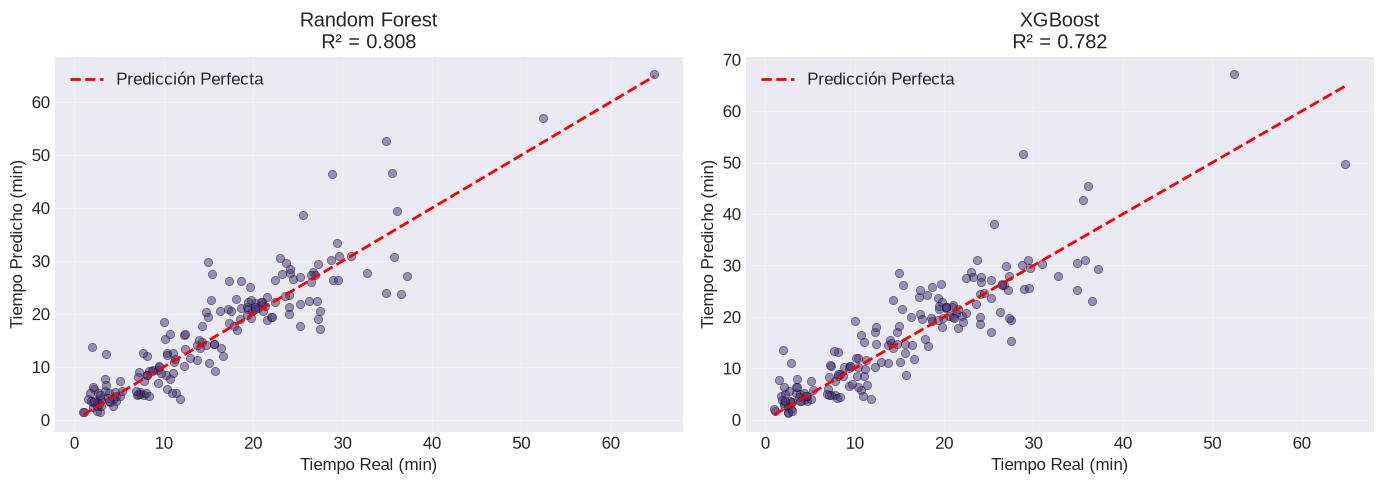


Análisis de Errores:
   Random Forest - Error medio: -0.78 min, Std: 4.53 min
   XGBoost - Error medio: -0.62 min, Std: 4.85 min

   ⚠ Random Forest SOBRESTIMA en promedio 0.78 min
      → El modelo predice más tiempo del que realmente toma

Análisis de Errores por Rango de Tiempo (Random Forest):
   0-10 min: n=60, Error medio=-0.76 min (±2.64) → Sobreestima
   10-20 min: n=57, Error medio=-1.33 min (±4.42) → Sobreestima
   20-30 min: n=45, Error medio=-0.43 min (±4.92) → Neutral
   30-50 min: n=9, Error medio=1.28 min (±10.48) → Subestima
   50+ min: n=2, Error medio=-2.55 min (±2.92) → Sobreestima

Análisis del Peor Caso (Max Error):
   Random Forest: 17.9 min
   XGBoost: 22.9 min

   Registro con mayor error en Random Forest:
   • Tiempo real: 34.8 min
   • Tiempo predicho: 52.7 min
   • Error: 17.9 min
   • Ruta: 8257


In [7]:
from sklearn.metrics import mean_absolute_percentage_error

def calcular_metricas(y_true, y_pred, nombre_modelo):
    """
    Calcula métricas de regresión para evaluación de modelos.
    
    Decisiones operativas:
    - MAE: Error promedio en minutos. Si es < 15 min, podemos planificar jornadas con precisión.
    - RMSE: Penaliza errores grandes. Crítico para evitar subestimar rutas pesadas.
    - R²: Capacidad explicativa del modelo.
    - MAPE: Error porcentual. Un MAPE < 20% es aceptable para planeación táctica.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    # MAPE seguro con mean_absolute_percentage_error de scikit-learn
    # Esto evita división por cero cuando y_true = 0
    try:
        mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    except:
        # Fallback: filtrar ceros para evitar división por cero
        mask = y_true != 0
        if mask.sum() > 0:
            mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
        else:
            mape = np.nan
    
    # Error máximo (para identificar peores casos)
    max_error = np.max(np.abs(y_true - y_pred))
    
    return {
        'Modelo': nombre_modelo,
        'MAE (min)': mae,
        'RMSE (min)': rmse,
        'R²': r2,
        'MAPE (%)': mape,
        'Max Error (min)': max_error
    }

# Calcular métricas
metricas_rf = calcular_metricas(y_test, y_pred_rf, 'Random Forest')
metricas_xgb = calcular_metricas(y_test, y_pred_xgb, 'XGBoost')

# Tabla comparativa
df_metricas = pd.DataFrame([metricas_rf, metricas_xgb])
print("=" * 50)
print("COMPARATIVA DE MODELOS")
print("=" * 50)
display(df_metricas.set_index('Modelo').round(2))

# Mejor modelo
mejor_modelo = 'Random Forest' if df_metricas.loc[0, 'MAE (min)'] < df_metricas.loc[1, 'MAE (min)'] else 'XGBoost'
print(f"\nMejor modelo: {mejor_modelo}")

# Visualización de predicciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, nombre in zip(axes, [y_pred_rf, y_pred_xgb], ['Random Forest', 'XGBoost']):
    ax.scatter(y_test, y_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción Perfecta')
    ax.set_xlabel('Tiempo Real (min)')
    ax.set_ylabel('Tiempo Predicho (min)')
    ax.set_title(f'{nombre}\nR² = {r2_score(y_test, y_pred):.3f}')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/predicciones_vs_reales.png', dpi=150, bbox_inches='tight')
plt.show()

# Análisis de errores
errores_rf = y_test - y_pred_rf
errores_xgb = y_test - y_pred_xgb

print("\nAnálisis de Errores:")
print(f"   Random Forest - Error medio: {errores_rf.mean():.2f} min, Std: {errores_rf.std():.2f} min")
print(f"   XGBoost - Error medio: {errores_xgb.mean():.2f} min, Std: {errores_xgb.std():.2f} min")

# Diagnóstico de sesgo: ¿Subestima o sobrestima?
sesgo_rf = errores_rf.mean()
if sesgo_rf > 0.5:
    print(f"\n   ⚠ Random Forest SUBESTIMA en promedio {sesgo_rf:.2f} min")
    print("      → El modelo predice menos tiempo del que realmente toma")
elif sesgo_rf < -0.5:
    print(f"\n   ⚠ Random Forest SOBRESTIMA en promedio {abs(sesgo_rf):.2f} min")
    print("      → El modelo predice más tiempo del que realmente toma")
else:
    print(f"\n   ✓ Random Forest tiene sesgo neutral ({sesgo_rf:.2f} min)")

# Análisis adicional: errores por rango de tiempo
print("\nAnálisis de Errores por Rango de Tiempo (Random Forest):")
bins = [0, 10, 20, 30, 50, 100]
labels = ['0-10 min', '10-20 min', '20-30 min', '30-50 min', '50+ min']
y_test_binned = pd.cut(y_test, bins=bins, labels=labels)

for label in labels:
    mask = y_test_binned == label
    if mask.sum() > 0:
        error_medio = errores_rf[mask].mean()
        error_std = errores_rf[mask].std()
        sesgo_label = "Subestima" if error_medio > 0.5 else ("Sobreestima" if error_medio < -0.5 else "Neutral")
        print(f"   {label}: n={mask.sum()}, Error medio={error_medio:.2f} min (±{error_std:.2f}) → {sesgo_label}")

# Análisis de errores por perfil de ruta (si está disponible)
if 'dificultad_cuartiles' in df_features.columns:
    print("\nAnálisis de Errores por Dificultad (Random Forest):")
    # Recuperar dificultad de las rutas en test
    dificultad_test = df_features.loc[X_test.index, 'dificultad_cuartiles']
    
    for dificultad in ['Difícil (bottom 25%)', 'Media (25-75%)', 'Fácil (top 25%)']:
        mask = dificultad_test == dificultad
        if mask.sum() > 0:
            error_medio = errores_rf[mask].mean()
            error_std = errores_rf[mask].std()
            sesgo_label = "Subestima" if error_medio > 0.5 else ("Sobreestima" if error_medio < -0.5 else "Neutral")
            print(f"   {dificultad}: n={mask.sum()}, Error medio={error_medio:.2f} min (±{error_std:.2f}) → {sesgo_label}")

# Análisis del peor caso (Max Error)
print("\nAnálisis del Peor Caso (Max Error):")
max_error_rf = metricas_rf['Max Error (min)']
max_error_xgb = metricas_xgb['Max Error (min)']
print(f"   Random Forest: {max_error_rf:.1f} min")
print(f"   XGBoost: {max_error_xgb:.1f} min")

# Identificar el registro con mayor error
idx_max_error = np.argmax(np.abs(y_test - y_pred_rf))
print(f"\n   Registro con mayor error en Random Forest:")
print(f"   • Tiempo real: {y_test.iloc[idx_max_error]:.1f} min")
print(f"   • Tiempo predicho: {y_pred_rf[idx_max_error]:.1f} min")
print(f"   • Error: {abs(y_test.iloc[idx_max_error] - y_pred_rf[idx_max_error]):.1f} min")
print(f"   • Ruta: {ruta_test.iloc[idx_max_error]}")

## 7. Identificación de Factores Clave <a id='importance'></a>
[Estructura](#estructura)


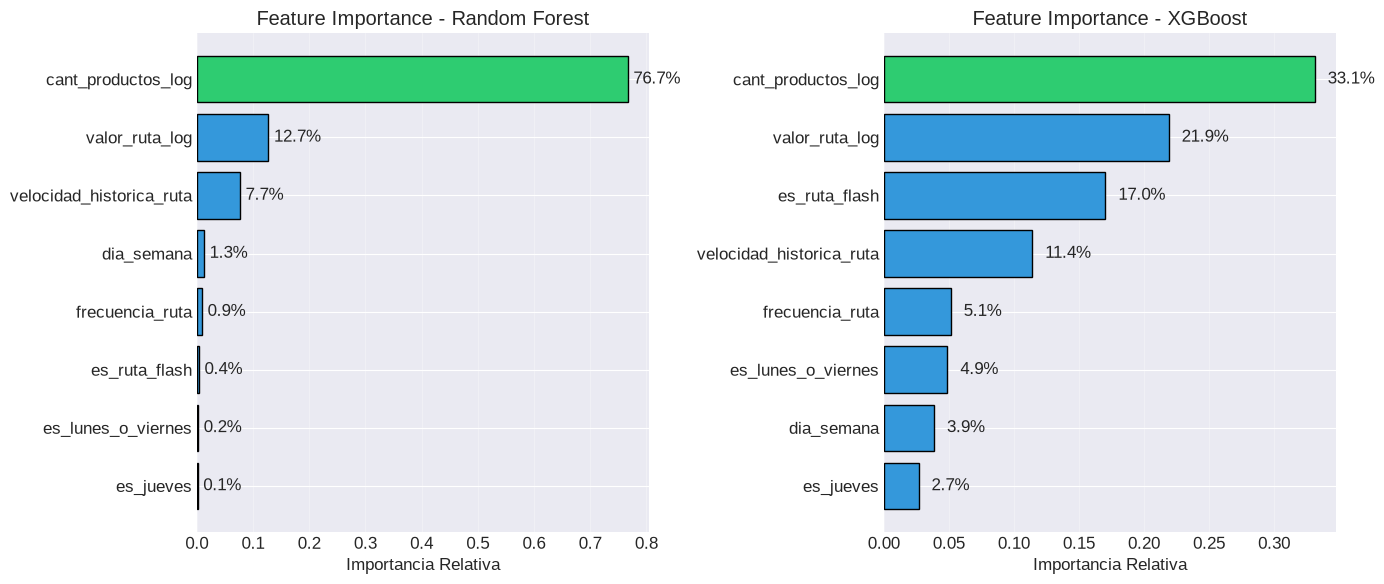

FEATURE IMPORTANCE - RANDOM FOREST


Cantidad Productos (log)       76.7% ██████████████████████████████████████
Valor Ruta (log)               12.7% ██████
Velocidad Histórica Ruta       7.7% ███
Día de Semana                  1.3% 
Frecuencia Ruta                0.9% 
Es Ruta Flash                  0.4% 
Es Lunes/Viernes               0.2% 
Es Jueves                      0.1% 


INSIGHT OPERATIVO CLAVE


Factor más influyente: Cantidad Productos (log) (original: cant_productos_log)
   Importancia: 76.7%
   Implicación: La cantidad de productos (en escala logarítmica) es el principal driver del tiempo de preparación

TOP 3 Factores (Random Forest):
   1. Cantidad Productos (log): 76.7%
   2. Valor Ruta (log): 12.7%
   3. Velocidad Histórica Ruta: 7.7%


CONSISTENCIA ENTRE MODELOS
Top 3 RF: Velocidad Histórica Ruta, Cantidad Productos (log), Valor Ruta (log)
Top 3 XGB: Es Ruta Flash, Cantidad Productos (log), Valor Ruta (log)
Coincidencia: 2/3 features


INTERPRETACIÓN DE VARIABLES TRA

In [8]:
# Extraer importancia de features
importancia_rf = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

importancia_xgb = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, importancia, nombre in zip(axes, [importancia_rf, importancia_xgb], 
                                   ['Random Forest', 'XGBoost']):
    colors = ['#2ecc71' if i == importancia['Importance'].max() else '#3498db' 
              for i in importancia['Importance']]
    ax.barh(importancia['Feature'], importancia['Importance'], color=colors, edgecolor='black')
    ax.set_xlabel('Importancia Relativa')
    ax.set_title(f'Feature Importance - {nombre}')
    ax.grid(axis='x', alpha=0.3)
    
    # Agregar valores
    for i, v in enumerate(importancia['Importance']):
        ax.text(v + 0.01, i, f'{v:.1%}', va='center')

plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Análisis de importancia
print("FEATURE IMPORTANCE - RANDOM FOREST")
print("\n")

# Tabla completa con nombres legibles
feature_names_legibles = {
    'cant_productos_log': 'Cantidad Productos (log)',
    'valor_ruta_log': 'Valor Ruta (log)',
    'dia_semana': 'Día de Semana',
    'es_jueves': 'Es Jueves',
    'es_lunes_o_viernes': 'Es Lunes/Viernes',
    'velocidad_historica_ruta': 'Velocidad Histórica Ruta',
    'frecuencia_ruta': 'Frecuencia Ruta',
    'es_ruta_flash': 'Es Ruta Flash'
}

for idx, row in importancia_rf.sort_values('Importance', ascending=False).iterrows():
    nombre_legible = feature_names_legibles.get(row['Feature'], row['Feature'])
    bar = '█' * int(row['Importance'] * 50)
    print(f"{nombre_legible:30} {row['Importance']:.1%} {bar}")

# Insight operativo
feature_top = importancia_rf.iloc[-1]
feature_top_legible = feature_names_legibles.get(feature_top['Feature'], feature_top['Feature'])

print("\n")
print("INSIGHT OPERATIVO CLAVE")
print("\n")
print(f"Factor más influyente: {feature_top_legible} (original: {feature_top['Feature']})")
print(f"   Importancia: {feature_top['Importance']:.1%}")
print(f"   Implicación: La cantidad de productos (en escala logarítmica) es el principal driver del tiempo de preparación")

print(f"\nTOP 3 Factores (Random Forest):")
for i, (idx, row) in enumerate(importancia_rf.tail(3).iloc[::-1].iterrows(), 1):
    nombre_legible = feature_names_legibles.get(row['Feature'], row['Feature'])
    print(f"   {i}. {nombre_legible}: {row['Importance']:.1%}")

# Consistencia entre modelos
print("\n")
print("CONSISTENCIA ENTRE MODELOS")
top_rf = set(importancia_rf.tail(3)['Feature'].values)
top_xgb = set(importancia_xgb.tail(3)['Feature'].values)
top_rf_legible = {feature_names_legibles.get(f, f) for f in top_rf}
top_xgb_legible = {feature_names_legibles.get(f, f) for f in top_xgb}

print(f"Top 3 RF: {', '.join(top_rf_legible)}")
print(f"Top 3 XGB: {', '.join(top_xgb_legible)}")
print(f"Coincidencia: {len(top_rf.intersection(top_xgb))}/3 features")

# Interpretación adicional para variables transformadas
print("\n")
print("INTERPRETACIÓN DE VARIABLES TRANSFORMADAS")
print("\n")
print("Nota: 'cant_productos_log' y 'valor_ruta_log' están en escala logarítmica.")
print("Esto significa que el modelo captura relaciones multiplicativas:")
print("   • Un incremento del 1% en productos tiene un impacto proporcional en el tiempo")
print("   • La transformación logarítmica reduce el efecto de valores extremos")

# Análisis de importancia acumulada
print("\n")
print("IMPORTANCIA ACUMULADA")
importancia_acumulada = importancia_rf.sort_values('Importance', ascending=False)
acumulado = importancia_acumulada['Importance'].cumsum()
for i, (idx, row) in enumerate(importancia_acumulada.iterrows(), 1):
    nombre_legible = feature_names_legibles.get(row['Feature'], row['Feature'])
    print(f"{i}. {nombre_legible}: {row['Importance']:.1%} (Acum: {acumulado.iloc[i-1]:.1%})")

print(f"\nLas primeras 3 features explican el {acumulado.iloc[2]:.1%} de la importancia total")

In [9]:
# Identificar rutas flash en el dataset
flash_train_ids = X_train[X_train['es_ruta_flash'] == 1].index.tolist()
flash_test_ids = X_test[X_test['es_ruta_flash'] == 1].index.tolist()

print("\n")
print("=" * 50)
print("FILTRADO DE RUTAS FLASH")
print("=" * 50)
print(f"\nRutas flash identificadas (umbral > 5,000 prod/h):")
print(f"   • Train: {len(flash_train_ids)} muestras ({len(flash_train_ids)/len(X_train)*100:.2f}%)")
print(f"   • Test:  {len(flash_test_ids)} muestras ({len(flash_test_ids)/len(X_test)*100:.2f}%)")

# Mostrar IDs de rutas flash en train (si existen)
if len(flash_train_ids) > 0:
    rutas_flash_train = X_train.loc[flash_train_ids].index.tolist()
    print(f"\n   IDs de rutas flash en Train: {', '.join(map(str, rutas_flash_train[:5]))}{'...' if len(rutas_flash_train) > 5 else ''}")

# Filtrar dataset sin rutas flash
mask_no_flash = X_train['es_ruta_flash'] == 0
X_train_noflash = X_train[mask_no_flash]
y_train_noflash = y_train[mask_no_flash]

X_test_noflash = X_test[X_test['es_ruta_flash'] == 0]
y_test_noflash = y_test[X_test['es_ruta_flash'] == 0]

print(f"\nDataset sin rutas flash:")
print(f"   • Train: {X_train_noflash.shape[0]} muestras ({X_train_noflash.shape[0]/len(X_train)*100:.1f}%)")
print(f"   • Test:  {X_test_noflash.shape[0]} muestras ({X_test_noflash.shape[0]/len(X_test)*100:.1f}%)")

# Entrenar modelo sin rutas flash
if len(X_train_noflash) > 50:
    print("\nEntrenando modelo sin rutas flash...")
    
    rf_noflash = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    rf_noflash.fit(X_train_noflash, y_train_noflash)
    y_pred_noflash = rf_noflash.predict(X_test_noflash)
    
    metricas_noflash = calcular_metricas(y_test_noflash, y_pred_noflash, 'RF sin Flash')
    
    # Comparativa de modelos
    print("\n")
    print("=" * 50)
    print("COMPARATIVA DE MODELOS")
    print("=" * 50)

    df_comparativa = pd.DataFrame([metricas_rf, metricas_xgb, metricas_noflash])
    display(df_comparativa.set_index('Modelo').round(2))
    
    # Análisis de impacto
    print("\n")
    print("=" * 50)
    print("ANALISIS DE SENSIBILIDAD")
    print("=" * 50)
    
    diff_mae = metricas_rf['MAE (min)'] - metricas_noflash['MAE (min)']
    diff_rmse = metricas_rf['RMSE (min)'] - metricas_noflash['RMSE (min)']
    diff_r2 = metricas_rf['R²'] - metricas_noflash['R²']
    diff_mape = metricas_rf['MAPE (%)'] - metricas_noflash['MAPE (%)']
    
    print(f"\nImpacto de incluir rutas flash (umbral > 5,000 prod/h):")
    print(f"   • MAE:  {diff_mae:+.2f} min")
    print(f"   • RMSE: {diff_rmse:+.2f} min")
    print(f"   • R²:   {diff_r2:+.3f}")
    print(f"   • MAPE: {diff_mape:+.1f}%")
    
    # Interpretación mejorada
    print("\n")
    print("INTERPRETACIÓN:")
    
    if abs(diff_mae) < 0.5 and abs(diff_r2) < 0.02:
        print("   ✓ Impacto mínimo de rutas flash")
        print("   → El modelo es robusto y generaliza bien")
        print("   → No se requiere modelo separado para rutas flash")
    elif diff_mae < 0 and diff_r2 > 0:
        print("   ✓ Rutas flash mejoran el modelo")
        print("   → Incluirlas aporta información valiosa")
        print("   → Mantener el modelo actual")
    else:
        print("   ⚠ Rutas flash tienen impacto significativo")
        print("   → Considerar modelo separado para rutas flash")
        print("   → O ajustar el umbral de clasificación")
        
else:
    print("Datos insuficientes para entrenar modelo sin rutas flash")
    print("   Se requieren más de 50 muestras en entrenamiento")

if len(X_train_noflash) > 50:
    # Análisis de impacto detallado
    print("\n")
    print("=" * 50)
    print("ANALISIS DE IMPACTO DETALLADO")
    print("=" * 50)
    
    diff_mae = metricas_rf['MAE (min)'] - metricas_noflash['MAE (min)']
    diff_r2 = metricas_rf['R²'] - metricas_noflash['R²']
    
    print(f"\nImpacto de incluir rutas flash:")
    print(f"   • MAE: {diff_mae:+.2f} min")
    print(f"   • R²:  {diff_r2:+.3f}")
    
    # Evaluación del impacto
    print("\nEvaluación:")
    if abs(diff_mae) < 0.5:
        print("   ✓ Modelo robusto - impacto mínimo")
        print("   → Las rutas flash no distorsionan el modelo")
    elif diff_mae < 0:
        print(f"   ✓ El modelo con rutas flash es mejor por {abs(diff_mae):.2f} min")
        print("   → Mantener las rutas flash en el dataset")
    else:
        print(f"   ⚠ El modelo sin rutas flash es mejor por {diff_mae:.2f} min")
        print("   → Considerar excluir rutas flash o tratarlas por separado")
    
    # Recomendación final
    print("\n")
    print("RECOMENDACIÓN FINAL:")
    if abs(diff_mae) < 0.5:
        print("   • Usar el modelo con todas las rutas (incluyendo flash)")
        print("   • El umbral de 5,000 prod/h es adecuado")
    else:
        print("   • Evaluar si se necesita un modelo específico para rutas flash")
        print("   • Considerar ajustar el umbral a 8,000 prod/h")



FILTRADO DE RUTAS FLASH

Rutas flash identificadas (umbral > 5,000 prod/h):
   • Train: 6 muestras (0.87%)
   • Test:  4 muestras (2.31%)

   IDs de rutas flash en Train: 237, 245, 330, 396, 446...

Dataset sin rutas flash:
   • Train: 684 muestras (99.1%)
   • Test:  169 muestras (97.7%)

Entrenando modelo sin rutas flash...


COMPARATIVA DE MODELOS


,MAE (min),RMSE (min),R²,MAPE (%),Max Error (min)
Modelo,,,,,
Random Forest,3.12,4.58,0.81,32.04,17.85
XGBoost,3.38,4.88,0.78,35.36,22.86
RF sin Flash,3.03,4.37,0.79,30.81,17.64




ANALISIS DE SENSIBILIDAD

Impacto de incluir rutas flash (umbral > 5,000 prod/h):
   • MAE:  +0.10 min
   • RMSE: +0.21 min
   • R²:   +0.013
   • MAPE: +1.2%


INTERPRETACIÓN:
   ✓ Impacto mínimo de rutas flash
   → El modelo es robusto y generaliza bien
   → No se requiere modelo separado para rutas flash


ANALISIS DE IMPACTO DETALLADO

Impacto de incluir rutas flash:
   • MAE: +0.10 min
   • R²:  +0.013

Evaluación:
   ✓ Modelo robusto - impacto mínimo
   → Las rutas flash no distorsionan el modelo


RECOMENDACIÓN FINAL:
   • Usar el modelo con todas las rutas (incluyendo flash)
   • El umbral de 5,000 prod/h es adecuado


## 8. Clustering de Rutas con K-Means <a id='clustering'></a>
[Estructura](#estructura)

### Segmentación de Rutas con K-Means

**K óptimo:** 2 clusters según coeficiente de silueta (0.86)


Datos agregados: 185 rutas únicas
Features seleccionadas: ['cant_productos_promedio', 'valor_ruta_promedio']
  • cant_productos_promedio: promedio de productos por ruta
  • valor_ruta_promedio: valor promedio por ruta

NOTA: Se usan las versiones originales (no logarítmicas) para mantener
      interpretabilidad en la segmentación.

Datos escalados: 185 muestras, 2 features
Rango de productos: 1 - 5507
Rango de valor: $7,550 - $16,547,801


OPTIMIZACIÓN DEL NÚMERO DE CLUSTERS
K=2: Silueta=0.8539, Inercia=320
K=3: Silueta=0.6961, Inercia=138
K=4: Silueta=0.6984, Inercia=74
K=5: Silueta=0.5847, Inercia=49
K=6: Silueta=0.5888, Inercia=40
K=7: Silueta=0.5622, Inercia=31
K=8: Silueta=0.5610, Inercia=24
K=9: Silueta=0.5075, Inercia=20
K=10: Silueta=0.4707, Inercia=17

✓ K óptimo según silueta: 2
   Coeficiente de silueta: 0.8539
   (Valores > 0.5 indican buena separación de clusters)


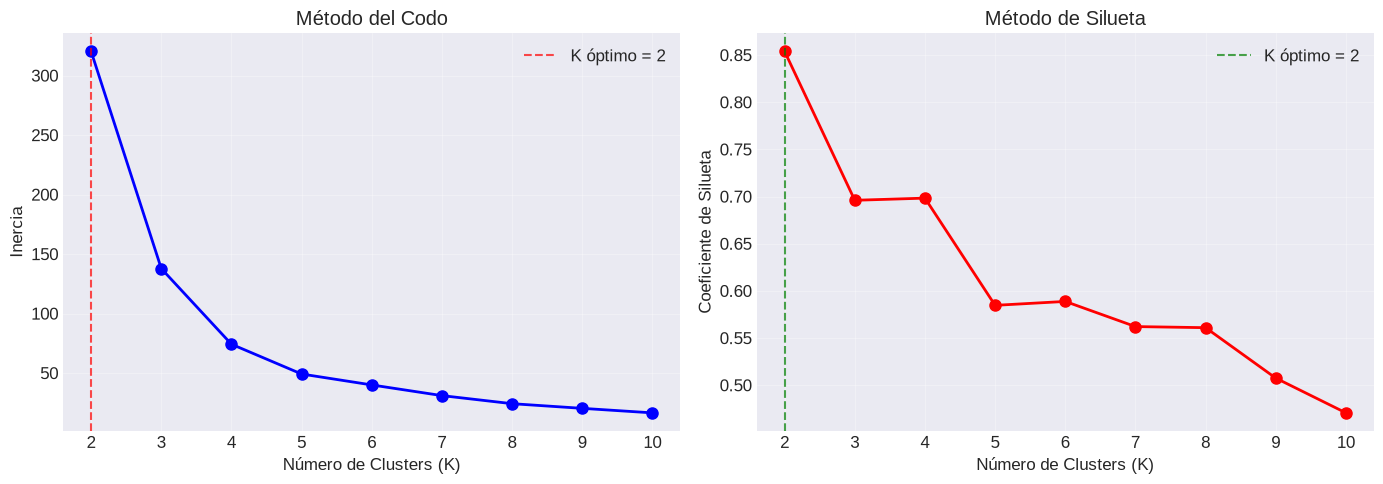



RESULTADO CLUSTERING

K óptimo: 2 clusters
Silueta promedio: 0.8539
Rutas clusterizadas: 185

CALIDAD DEL CLUSTERING:
   ✓ Excelente separación entre clusters


PERFILADO DE CLUSTERS

Resumen por cluster:


,cluster,rutas_count,prod_promedio,valor_promedio,tiempo_promedio,velocidad_promedio
0,0,180,330.8,1427526.3,12.9,1406.2
1,1,5,3169.0,11740528.6,40.0,4549.7




ANÁLISIS DE BALANCE
Cluster 0: 180 rutas (97.3%)
   ⚠ Cluster muy grande - considerar dividir o ajustar K
Cluster 1: 5 rutas (2.7%)
   ⚠ Cluster pequeño - posible outlier o segmento especializado


ETIQUETAS OPERATIVAS
Cluster 0 (Normales): 180 rutas (97.3%)
Cluster 1 (Estrella): 5 rutas (2.7%)


In [10]:
from sklearn.preprocessing import RobustScaler

# PREPARAR DATOS PARA CLUSTERING

df_cluster = df_clean.groupby('id_ruta').agg(
    cant_productos_promedio=('cant_productos', 'mean'),
    valor_ruta_promedio=('valor_ruta', 'mean'),
    tiempo_promedio=('tiempo_preparacion_minutos', 'mean'),
    velocidad_promedio=('velocidad_despacho', 'mean'),
    frecuencia=('id_ruta', 'count')
).reset_index()

print(f"Datos agregados: {len(df_cluster)} rutas únicas")

# Features para clustering
# Opción 1: Perfil Comercial (Volumen + Valor)
features_cluster_negocio = ['cant_productos_promedio', 'valor_ruta_promedio']

# Opción 2: Perfil Logístico (Volumen + Tiempo) - más relevante para operaciones
features_cluster_logistica = ['cant_productos_promedio', 'tiempo_promedio']

# Opción 3: Perfil Integral (Volumen + Velocidad) - eficiencia operativa
features_cluster_eficiencia = ['cant_productos_promedio', 'velocidad_promedio']

# Decisión: Usar Perfil Comercial para mantener consistencia con análisis anterior
# Pero considerar que los outliers pueden afectar
features_cluster = features_cluster_negocio

print(f"Features seleccionadas: {features_cluster}")
print(f"  • cant_productos_promedio: promedio de productos por ruta")
print(f"  • valor_ruta_promedio: valor promedio por ruta")
print("\nNOTA: Se usan las versiones originales (no logarítmicas) para mantener")
print("      interpretabilidad en la segmentación.")

# ESCALAR FEATURES CON ROBUSTSCALER (manejo de outliers)

# Usar RobustScaler en lugar de StandardScaler
# RobustScaler usa mediana y cuartiles, menos sensible a outliers
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_cluster[features_cluster])

print(f"\nDatos escalados: {X_scaled.shape[0]} muestras, {X_scaled.shape[1]} features")
print(f"Rango de productos: {df_cluster['cant_productos_promedio'].min():.0f} - {df_cluster['cant_productos_promedio'].max():.0f}")
print(f"Rango de valor: ${df_cluster['valor_ruta_promedio'].min():,.0f} - ${df_cluster['valor_ruta_promedio'].max():,.0f}")

# OPTIMIZACIÓN DEL NÚMERO DE CLUSTERS

print("\n")
print("=" * 50)
print("OPTIMIZACIÓN DEL NÚMERO DE CLUSTERS")
print("=" * 50)

k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, kmeans.labels_)
    silhouettes.append(sil_score)
    print(f"K={k}: Silueta={sil_score:.4f}, Inercia={kmeans.inertia_:.0f}")

# K óptimo
k_optimo = k_range[np.argmax(silhouettes)]
print(f"\n✓ K óptimo según silueta: {k_optimo}")
print(f"   Coeficiente de silueta: {max(silhouettes):.4f}")
print(f"   (Valores > 0.5 indican buena separación de clusters)")

# VISUALIZACIÓN

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Método del Codo
axes[0].plot(k_range, inertias, 'bo-', markersize=8, linewidth=2)
axes[0].axvline(x=k_optimo, color='red', linestyle='--', alpha=0.7, 
                label=f'K óptimo = {k_optimo}')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Método de Silueta
axes[1].plot(k_range, silhouettes, 'ro-', markersize=8, linewidth=2)
axes[1].axvline(x=k_optimo, color='green', linestyle='--', alpha=0.7,
                label=f'K óptimo = {k_optimo}')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Coeficiente de Silueta')
axes[1].set_title('Método de Silueta')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/kmeans_optimizacion.png', dpi=150, bbox_inches='tight')
plt.show()

# RESULTADO FINAL

print("\n")
print("=" * 50)
print("RESULTADO CLUSTERING")
print("=" * 50)

print(f"\nK óptimo: {k_optimo} clusters")
print(f"Silueta promedio: {max(silhouettes):.4f}")
print(f"Rutas clusterizadas: {len(df_cluster)}")

# Interpretación de la calidad del clustering
print("\nCALIDAD DEL CLUSTERING:")
if max(silhouettes) > 0.7:
    print("   ✓ Excelente separación entre clusters")
elif max(silhouettes) > 0.5:
    print("   ✓ Buena separación entre clusters")
elif max(silhouettes) > 0.3:
    print("   • Separación aceptable entre clusters")
else:
    print("   ⚠ Separación débil - considerar otras features o método")

# ENTREGA: PERFILADO DE CLUSTERS

print("\n")
print("=" * 50)
print("PERFILADO DE CLUSTERS")
print("=" * 50)

# Entrenar K-Means con K óptimo
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans_final.fit_predict(X_scaled)

# Ver las medias reales por cluster (en unidades de negocio)
resumen_clusters = df_cluster.groupby('cluster').agg(
    rutas_count=('id_ruta', 'count'),
    prod_promedio=('cant_productos_promedio', 'mean'),
    valor_promedio=('valor_ruta_promedio', 'mean'),
    tiempo_promedio=('tiempo_promedio', 'mean'),
    velocidad_promedio=('velocidad_promedio', 'mean')
).round(1).reset_index()

print("\nResumen por cluster:")
display(resumen_clusters)

# ANÁLISIS DE BALANCE DE CLUSTERS

print("\n")
print("=" * 50)
print("ANÁLISIS DE BALANCE")
print("=" * 50)

for cluster in sorted(df_cluster['cluster'].unique()):
    count = (df_cluster['cluster'] == cluster).sum()
    pct = count / len(df_cluster) * 100
    print(f"Cluster {cluster}: {count} rutas ({pct:.1f}%)")
    
    # Detectar clusters desbalanceados
    if count < len(df_cluster) * 0.05:
        print(f"   ⚠ Cluster pequeño - posible outlier o segmento especializado")
    elif count > len(df_cluster) * 0.80:
        print(f"   ⚠ Cluster muy grande - considerar dividir o ajustar K")

# ASIGNAR ETIQUETAS OPERATIVAS

print("\n")
print("=" * 50)
print("ETIQUETAS OPERATIVAS")
print("=" * 50)

# Asignar etiquetas basadas en velocidad
cluster_profile = df_cluster.groupby('cluster').agg(
    velocidad_promedio=('velocidad_promedio', 'mean')
).reset_index()

cluster_profile['dificultad'] = pd.cut(
    cluster_profile['velocidad_promedio'], 
    bins=[0, 842, 2279, float('inf')],
    labels=['Pesadas', 'Normales', 'Estrella']
)

for cluster in sorted(df_cluster['cluster'].unique()):
    perfil = cluster_profile[cluster_profile['cluster'] == cluster]['dificultad'].values[0]
    count = (df_cluster['cluster'] == cluster).sum()
    pct = count / len(df_cluster) * 100
    print(f"Cluster {cluster} ({perfil}): {count} rutas ({pct:.1f}%)")




PERFIL DE CLUSTERS OPERATIVOS




,num_rutas,productos_promedio,valor_promedio,tiempo_promedio,velocidad_promedio,dificultad
cluster,,,,,,
0,180,330.8,1427526.3,12.9,1406.2,Normales
1,5,3169.0,11740528.6,40.0,4549.7,Estrella




DISTRIBUCIÓN DE CLUSTERS


Cluster 0 (Normales): 180 rutas (97.3%)
Cluster 1 (Estrella): 5 rutas (2.7%)


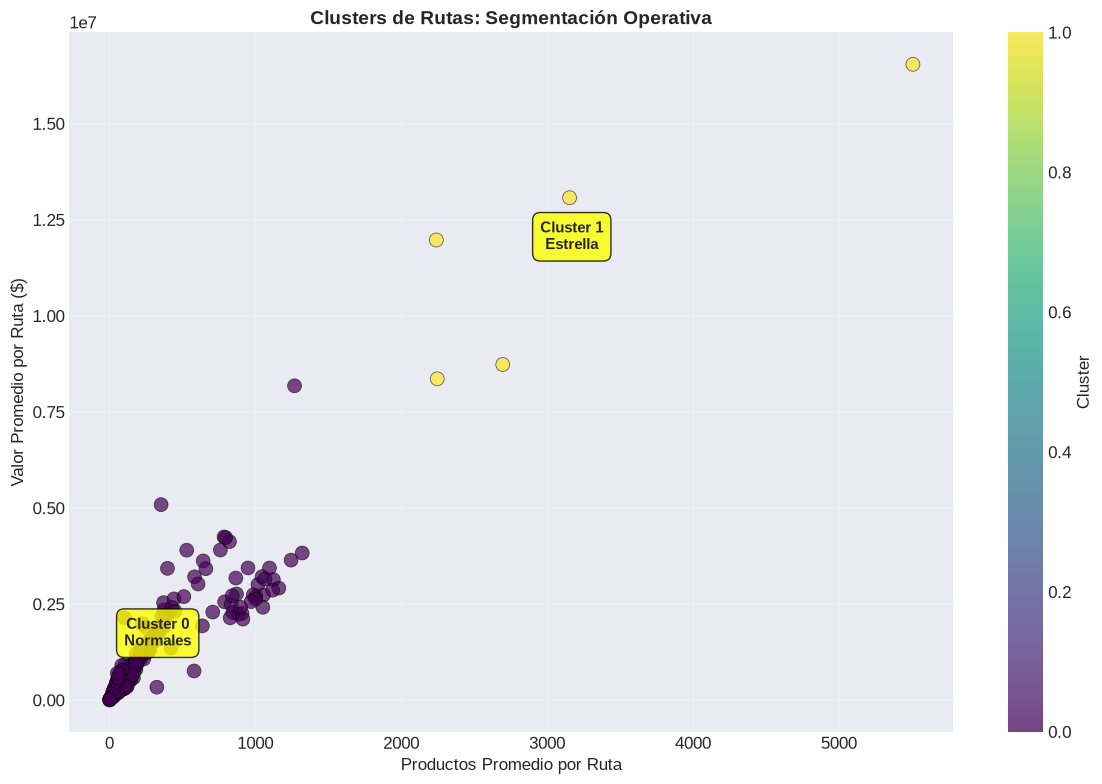



CENTROIDES DE CLUSTERS


,cant_productos_promedio,valor_ruta_promedio,cluster,perfil
0,331.0,1427526.0,0,Normales
1,3169.0,11740529.0,1,Estrella




MAPEO DE RUTAS A CLUSTERS


Primeras 10 rutas:


,id_ruta,cluster,perfil
0,12,0,Normales
1,201,0,Normales
2,207,0,Normales
3,209,0,Normales
4,210,0,Normales
5,211,0,Normales
6,212,0,Normales
7,213,0,Normales
8,251,0,Normales
9,252,0,Normales




VERIFICACIÓN DE CONSISTENCIA

Distribución de dificultad por cluster (%):


dificultad_cuartiles,Difícil (bottom 25%),Fácil (top 25%),Media (25-75%)
cluster,,,
0,35.6,16.1,48.3
1,0.0,100.0,0.0



Análisis:
Cluster 0 (Normales):
   • Dificultad predominante: Media (25-75%) (48.3%)
   ⚠ Discrepancia: El perfil 'Normales' no coincide con 'Media (25-75%)'
Cluster 1 (Estrella):
   • Dificultad predominante: Fácil (top 25%) (100.0%)
   ⚠ Discrepancia: El perfil 'Estrella' no coincide con 'Fácil (top 25%)'


RESUMEN DE CLUSTERING

Total rutas: 185
Clusters: 2
Perfiles: Normales, Estrella
Mayor cluster: 0 (180 rutas)


RECOMENDACIONES OPERATIVAS


Cluster 0 - Normales (180 rutas):
   • Productos promedio: 331
   • Valor promedio: $1,427,526
   → Asignación estándar
   → Personal con capacitación básica

Cluster 1 - Estrella (5 rutas):
   • Productos promedio: 3169
   • Valor promedio: $11,740,529
   → Asignar personal experto
   → Priorizar en la planificación diaria



In [11]:
# Entrenar K-Means con K óptimo
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans_final.fit_predict(X_scaled)

# Caracterización de Clusters
cluster_profile = df_cluster.groupby('cluster').agg(
    num_rutas=('id_ruta', 'count'),
    productos_promedio=('cant_productos_promedio', 'mean'),
    valor_promedio=('valor_ruta_promedio', 'mean'),
    tiempo_promedio=('tiempo_promedio', 'mean'),
    velocidad_promedio=('velocidad_promedio', 'mean')
).round(1)

# Asignar etiquetas operativas
cluster_profile['dificultad'] = pd.cut(
    cluster_profile['velocidad_promedio'], 
    bins=[0, 842, 2279, float('inf')],
    labels=['Pesadas', 'Normales', 'Estrella']
)

print("\n")
print("=" * 50)
print("PERFIL DE CLUSTERS OPERATIVOS")
print("=" * 50)
print("\n")
display(cluster_profile)

# Distribución de Clusters
print("\n")
print("DISTRIBUCIÓN DE CLUSTERS")
print("\n")

for cluster in sorted(df_cluster['cluster'].unique()):
    count = (df_cluster['cluster'] == cluster).sum()
    pct = count / len(df_cluster) * 100
    perfil = cluster_profile.loc[cluster, 'dificultad']
    print(f"Cluster {cluster} ({perfil}): {count} rutas ({pct:.1f}%)")

# Visualización de Cluster
plt.figure(figsize=(12, 8))

# Scatter plot
scatter = plt.scatter(
    df_cluster['cant_productos_promedio'], 
    df_cluster['valor_ruta_promedio'],
    c=df_cluster['cluster'], 
    cmap='viridis', 
    s=100, 
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)

plt.xlabel('Productos Promedio por Ruta', fontsize=12)
plt.ylabel('Valor Promedio por Ruta ($)', fontsize=12)
plt.title('Clusters de Rutas: Segmentación Operativa', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

# Añadir centroides
centroids = scaler.inverse_transform(kmeans_final.cluster_centers_)
for i, (x, y) in enumerate(centroids):
    perfil = cluster_profile.loc[i, 'dificultad']
    plt.annotate(
        f'Cluster {i}\n{perfil}', 
        (x, y), 
        fontsize=11, 
        ha='center',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8, edgecolor='black')
    )

plt.tight_layout()
plt.savefig('../reports/figures/clusters_rutas.png', dpi=150, bbox_inches='tight')
plt.show()

# Centroides de Clusters
print("\n")
print("=" * 50)
print("CENTROIDES DE CLUSTERS")
print("=" * 50)

centroids_df = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=features_cluster
)
centroids_df['cluster'] = range(k_optimo)
centroids_df['perfil'] = centroids_df['cluster'].map(
    cluster_profile['dificultad'].to_dict()
)
display(centroids_df.round(0))

# Mapeo de Rutas a Clusters
ruta_cluster_map = df_cluster[['id_ruta', 'cluster']].copy()
ruta_cluster_map['perfil'] = ruta_cluster_map['cluster'].map(
    cluster_profile['dificultad'].to_dict()
)

print("\n")
print("=" * 50)
print("MAPEO DE RUTAS A CLUSTERS")
print("=" * 50)
print("\n")
print("Primeras 10 rutas:")
display(ruta_cluster_map.head(10))

# Verificación de consistencia con dificultad_cuartiles
print("\n")
print("=" * 50)
print("VERIFICACIÓN DE CONSISTENCIA")
print("=" * 50)

# Mapear dificultad_cuartiles a df_cluster
df_cluster_with_dificultad = df_cluster.merge(
    df_clean[['id_ruta', 'dificultad_cuartiles']].drop_duplicates('id_ruta'),
    on='id_ruta',
    how='left'
)

# Tabla de contingencia
contingencia = pd.crosstab(
    df_cluster_with_dificultad['cluster'],
    df_cluster_with_dificultad['dificultad_cuartiles'],
    normalize='index'
) * 100

print("\nDistribución de dificultad por cluster (%):")
display(contingencia.round(1))

# Análisis de consistencia
print("\nAnálisis:")
for cluster in sorted(df_cluster['cluster'].unique()):
    perfil = cluster_profile.loc[cluster, 'dificultad']
    dificultad_predominante = contingencia.loc[cluster].idxmax()
    pct_dominante = contingencia.loc[cluster].max()
    print(f"Cluster {cluster} ({perfil}):")
    print(f"   • Dificultad predominante: {dificultad_predominante} ({pct_dominante:.1f}%)")
    
    if perfil in dificultad_predominante:
        print(f"   ✓ Coherente: El perfil '{perfil}' coincide con la dificultad predominante")
    else:
        print(f"   ⚠ Discrepancia: El perfil '{perfil}' no coincide con '{dificultad_predominante}'")

# Resumen final
print("\n")
print("=" * 50)
print("RESUMEN DE CLUSTERING")
print("=" * 50)

print(f"\nTotal rutas: {len(df_cluster)}")
print(f"Clusters: {k_optimo}")
print(f"Perfiles: {', '.join(cluster_profile['dificultad'].unique())}")
print(f"Mayor cluster: {cluster_profile['num_rutas'].idxmax()} ({cluster_profile['num_rutas'].max()} rutas)")

# Recomendaciones operativas
print("\n")
print("RECOMENDACIONES OPERATIVAS")
print("\n")

for cluster in sorted(df_cluster['cluster'].unique()):
    perfil = cluster_profile.loc[cluster, 'dificultad']
    num_rutas = cluster_profile.loc[cluster, 'num_rutas']
    productos = cluster_profile.loc[cluster, 'productos_promedio']
    valor = cluster_profile.loc[cluster, 'valor_promedio']
    
    print(f"Cluster {cluster} - {perfil} ({num_rutas} rutas):")
    print(f"   • Productos promedio: {productos:.0f}")
    print(f"   • Valor promedio: ${valor:,.0f}")
    
    if perfil == 'Estrella':
        print("   → Asignar personal experto")
        print("   → Priorizar en la planificación diaria")
    elif perfil == 'Pesadas':
        print("   → Considerar apoyo adicional")
        print("   → Evaluar división de la ruta si es posible")
    else:  # Normales
        print("   → Asignación estándar")
        print("   → Personal con capacitación básica")
    print()

## 9. Simulador de Jornada Operativa <a id='simulacion'></a>
[Estructura](#estructura)

### Herramienta de Decisión

El simulador integra el modelo predictivo y la segmentación de rutas para apoyar la planificación operativa diaria.

**Funcionalidades:**
- Estimar tiempo total de jornada basado en rutas seleccionadas
- Identificar rutas críticas que requieren atención especial
- Generar recomendaciones operativas personalizadas
- Visualizar distribución de tiempos por ruta

**Features usadas:** `cant_productos_log`, `valor_ruta_log`, `dia_semana`, `es_jueves`, `es_lunes_o_viernes`, `velocidad_historica_ruta`, `frecuencia_ruta`, `es_ruta_flash`


In [12]:
class SimuladorJornadaV2:
    """
    Simula una jornada aceptando fecha de simulación para calcular correctamente
    los features temporales (día de semana, es_jueves, es_lunes_o_viernes).
    """
    
    def __init__(self, modelo, scaler, ruta_cluster_map, feature_cols, df_features):
        self.modelo = modelo
        self.scaler = scaler
        self.ruta_cluster_map = ruta_cluster_map
        self.feature_cols = feature_cols
        self.df_features = df_features
        self.rutas_nuevas = []
        
        # Estadísticas por ruta (para cold start)
        # NOTA: Se usan las versiones transformadas para consistencia con el modelo
        self.ruta_stats = df_features.groupby('id_ruta').agg(
            velocidad_historica_ruta=('velocidad_historica_ruta', 'mean'),
            frecuencia_ruta=('frecuencia_ruta', 'mean'),
            es_ruta_flash=('es_ruta_flash', 'max'),
            cant_productos_log_promedio=('cant_productos_log', 'mean'),
            valor_ruta_log_promedio=('valor_ruta_log', 'mean')
        ).reset_index()
        
    def preparar_features_ruta(self, ruta_id, fecha_simulacion=None):
        """
        Prepara features para una ruta específica en una FECHA determinada.
        
        Parámetros:
        - ruta_id: ID de la ruta
        - fecha_simulacion: Fecha para la cual se simula (datetime o string 'YYYY-MM-DD')
        """
        
        # Convertir fecha_simulacion a datetime si es string
        if fecha_simulacion is not None:
            if isinstance(fecha_simulacion, str):
                fecha_simulacion = pd.to_datetime(fecha_simulacion)
            
            # Calcular features temporales basados en la fecha de la simulación
            dia_semana = fecha_simulacion.dayofweek  # 0=Lunes, 6=Domingo
            es_jueves = 1 if dia_semana == 3 else 0
            es_lunes_o_viernes = 1 if dia_semana in [0, 4] else 0
        else:
            # Si no se especifica fecha, usar valores promedio (neutral)
            print("No se especificó fecha. Usando día neutro (Miércoles).")
            dia_semana = 2  # Miércoles como día neutro
            es_jueves = 0
            es_lunes_o_viernes = 0
        
        # Buscar la ruta en el histórico para features específicos
        ruta_info = self.ruta_stats[self.ruta_stats['id_ruta'] == ruta_id]
        
        if len(ruta_info) == 0:
            # Ruta nueva - Cold Start
            print(f"Ruta {ruta_id} es NUEVA. Usando perfil promedio.")
            self.rutas_nuevas.append(ruta_id)
            
            # CORRECCION: Usar versiones logarítmicas para consistencia
            features_dict = {
                'cant_productos_log': self.df_features['cant_productos_log'].median(),
                'valor_ruta_log': self.df_features['valor_ruta_log'].median(),
                'dia_semana': dia_semana,
                'es_jueves': es_jueves,
                'es_lunes_o_viernes': es_lunes_o_viernes,
                'velocidad_historica_ruta': self.df_features['velocidad_historica_ruta'].median(),
                'frecuencia_ruta': 1,  # Primera vez
                'es_ruta_flash': 0     # Asumir que no es flash
            }
        else:
            # Ruta existente - Usar datos históricos de la ruta
            ruta_info = ruta_info.iloc[0]
            
            # CORRECCION: Usar versiones logarítmicas para consistencia
            features_dict = {
                'cant_productos_log': ruta_info['cant_productos_log_promedio'],
                'valor_ruta_log': ruta_info['valor_ruta_log_promedio'],
                'dia_semana': dia_semana,       
                'es_jueves': es_jueves,             
                'es_lunes_o_viernes': es_lunes_o_viernes, 
                'velocidad_historica_ruta': ruta_info['velocidad_historica_ruta'],
                'frecuencia_ruta': ruta_info['frecuencia_ruta'],
                'es_ruta_flash': int(ruta_info['es_ruta_flash'])
            }
        
        # Crear DataFrame con una fila
        return pd.DataFrame([features_dict])[self.feature_cols]
    
    def simular_jornada(self, lista_rutas, fecha_simulacion=None, jornada_maxima=480, verbose=True):
        """
        Simula una jornada completa para una FECHA específica.
        
        Parámetros:
        - lista_rutas: Lista de IDs de ruta a despachar
        - fecha_simulacion: Fecha para la simulación (string 'YYYY-MM-DD' o datetime)
        - jornada_maxima: Tiempo máximo en minutos (default: 480 = 8h)
        - verbose: Mostrar detalle
        
        Retorna:
        - DataFrame con resultados por ruta
        - Tiempo total estimado
        - Alertas y recomendaciones
        """
        
        self.rutas_nuevas = []
        resultados = []
        tiempo_total = 0
        alertas = []
        
        # Validar fecha
        if fecha_simulacion is None:
            fecha_simulacion = pd.Timestamp.now()
            print("No se especificó fecha. Usando fecha actual.")
        
        if isinstance(fecha_simulacion, str):
            fecha_simulacion = pd.to_datetime(fecha_simulacion)
        
        # Información del día
        nombre_dia = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo'][fecha_simulacion.dayofweek]
        es_finde = fecha_simulacion.dayofweek >= 5
        
        if verbose:
            print("=" * 60)
            print("SIMULADOR DE JORNADA")
            print("=" * 60)
            print("\n")
            print(f"Fecha: {fecha_simulacion.strftime('%Y-%m-%d')} ({nombre_dia})")
            print(f"Jornada máxima: {jornada_maxima} min ({jornada_maxima/60:.1f} hrs)")
            print(f"Rutas a despachar: {len(lista_rutas)}")
            
            # Alertas de día
            if fecha_simulacion.dayofweek == 3:  # Jueves
                print("✓ DÍA FAVORABLE: Jueves (mejor rendimiento histórico)")
            elif fecha_simulacion.dayofweek in [0, 4]:  # Lunes o Viernes
                print("⚠ DÍA COMPLEJO: Lunes/Viernes (menor rendimiento histórico)")
            
            if es_finde:
                print("⚠ FIN DE SEMANA: Considerar ajustes de personal")
            
            print("\n")
            print("-" * 60)
        
        for i, ruta_id in enumerate(lista_rutas, 1):
            try:
                # Preparar features con la fecha correcta
                X_ruta = self.preparar_features_ruta(ruta_id, fecha_simulacion)
                tiempo_pred = self.modelo.predict(X_ruta)[0]
                tiempo_pred = max(0, tiempo_pred)
                
                # Obtener perfil de cluster
                cluster_info = self.ruta_cluster_map[
                    self.ruta_cluster_map['id_ruta'] == ruta_id
                ]
                
                if len(cluster_info) > 0:
                    perfil = cluster_info['perfil'].values[0]
                else:
                    perfil = 'Normales'  # Default para nuevas rutas
                
                tiempo_total += tiempo_pred
                excede = tiempo_total > jornada_maxima
                
                # Alertas
                if 'Pesadas' in str(perfil) and tiempo_pred > 120:
                    alertas.append({
                        'ruta': ruta_id,
                        'tiempo': tiempo_pred,
                        'perfil': perfil,
                        'recomendacion': 'Asignar apoyo adicional'
                    })
                
                resultados.append({
                    'Orden': i,
                    'Ruta': int(ruta_id),
                    'Tiempo (min)': round(tiempo_pred, 1),
                    'Acumulado (min)': round(tiempo_total, 1),
                    'Perfil': perfil,
                    'Excede': '⚠ EXCEDE' if excede else '✓ OK'
                })
                
                if verbose:
                    excede_str = '⚠ EXCEDE' if excede else ''
                    print(f"  {i:2d}. Ruta {ruta_id:5d}: {tiempo_pred:6.1f} min | "
                          f"Acum: {tiempo_total:6.1f} min | {perfil:10} {excede_str}")
                    
            except Exception as e:
                print(f"  Error en ruta {ruta_id}: {str(e)}")
        
        df_resultados = pd.DataFrame(resultados)
        
        if verbose:
            print("-" * 60)
            print("\n")
            print("=" * 60)
            print(f"RESUMEN DE JORNADA - {nombre_dia} {fecha_simulacion.strftime('%d/%m/%Y')}")
            print("=" * 60)
            print(f"Tiempo total: {tiempo_total:.1f} min ({tiempo_total/60:.2f} hrs)")
            
            if tiempo_total > jornada_maxima:
                exceso = tiempo_total - jornada_maxima
                print(f"⚠ EXCEDE jornada en {exceso:.0f} min ({exceso/60:.1f} hrs)")
                print(f"   Requiere {exceso/60:.1f} hrs extra O redistribuir {int(exceso/30)} rutas aprox.")
            else:
                holgura = jornada_maxima - tiempo_total
                print(f"✓ DENTRO de jornada. Holgura: {holgura:.0f} min ({holgura/60:.1f} hrs)")
            
            # Distribución de perfiles
            if len(df_resultados) > 0:
                estrellas = df_resultados[df_resultados['Perfil'].str.contains('Estrella', na=False)]
                pesadas = df_resultados[df_resultados['Perfil'].str.contains('Pesadas', na=False)]
                normales = df_resultados[~df_resultados['Perfil'].isin(
                    estrellas['Perfil'].tolist() + pesadas['Perfil'].tolist()
                )]
                
                print(f"\nDISTRIBUCIÓN DE PERFILES:")
                print(f"   Estrella: {len(estrellas)} rutas")
                print(f"   Pesadas:  {len(pesadas)} rutas")
                print(f"   Normales: {len(normales)} rutas")
            
            # Recomendaciones
            print(f"\nRECOMENDACIONES PARA {nombre_dia.upper()}:")
            
            if fecha_simulacion.dayofweek == 3:  # Jueves
                print("   ✓ Día de alta productividad. Aprovechar para rutas complejas.")
            elif fecha_simulacion.dayofweek in [0, 4]:
                print("   ⚠ Día complejo. Iniciar con rutas sencillas como calentamiento.")
            
            if len(estrellas) > 0:
                print(f"   ★ {len(estrellas)} rutas Estrella: Personal experto (alto volumen)")
            if len(pesadas) > 0:
                print(f"   ■ {len(pesadas)} rutas Pesadas: Considerar apoyo o división")
            
            if tiempo_total > jornada_maxima * 0.85:
                print(f"   ⚠ Jornada al {tiempo_total/jornada_maxima*100:.0f}%. Poca holgura para imprevistos.")
            else:
                print(f"   ✓ Jornada al {tiempo_total/jornada_maxima*100:.0f}%. Holgura suficiente.")
            
            if len(self.rutas_nuevas) > 0:
                print(f"\n   ℹ Rutas nuevas detectadas: {', '.join(map(str, self.rutas_nuevas))}")
                print("      Se usaron promedios globales para estimar tiempos.")
            
            print("=" * 60)
        
        return df_resultados, tiempo_total, alertas

# Inicializar el simulador
print("Inicializando Simulador de Jornada")
print("-" * 40)

simulador = SimuladorJornadaV2(
    modelo=rf_model,           # Mejor modelo (Random Forest)
    scaler=scaler,
    ruta_cluster_map=ruta_cluster_map,
    feature_cols=feature_cols,
    df_features=df_features
)

print("\n✓ Simulador listo para usar!")
print(f"   Modelo: Random Forest")
print(f"   Features: {len(feature_cols)}")
print(f"   Rutas en mapa: {len(ruta_cluster_map)}")

Inicializando Simulador de Jornada
----------------------------------------

✓ Simulador listo para usar!
   Modelo: Random Forest
   Features: 8
   Rutas en mapa: 185


## 10. Prueba de Simulador de Jornada
[Estructura](#estructura)

Permite simular diferentes escenarios validar la herramienta.

In [13]:
# Simular jornada de día anterior
fecha_simulacion = '2026-08-08'

rutas_ayer = [
        9376, 9375, 8002, 9378, 9379, 9384, 9386, 9390, 7603, 7606,
    7613, 7628, 7644, 7648, 7664, 7656, 7674, 7691, 7732, 307, 310,
    201, 212, 256, 264
]

print("=" * 60)
print("SIMULACIÓN DE JORNADA")
print("=" * 60)
print(f"\nFecha simulada: {fecha_simulacion}")
print(f"Total rutas: {len(rutas_ayer)}")
print(f"Jornada máxima: 480 min (8.0 hrs)")
print("-" * 60)

# Ejecutar simulación
df_resultado, tiempo_total, alertas = simulador.simular_jornada(
    lista_rutas=rutas_ayer,
    fecha_simulacion=fecha_simulacion,
    jornada_maxima=480,    
    verbose=True
)

# Mostrar tabla de resultados con formato mejorado
print("\n")
print("=" * 60)
print("DETALLE POR RUTA")
print("=" * 60)
display(df_resultado)

# Análisis adicional de resultados
print("\n")
print("=" * 60)
print("ANÁLISIS DE RESULTADOS")
print("=" * 60)

# Estadísticas de tiempos
print(f"\nEstadísticas de tiempos por ruta:")
print(f"   • Tiempo mínimo: {df_resultado['Tiempo (min)'].min():.1f} min")
print(f"   • Tiempo máximo: {df_resultado['Tiempo (min)'].max():.1f} min")
print(f"   • Tiempo promedio: {df_resultado['Tiempo (min)'].mean():.1f} min")
print(f"   • Desviación estándar: {df_resultado['Tiempo (min)'].std():.1f} min")

# Rutas que más tiempo consumen
top_5_tiempo = df_resultado.nlargest(5, 'Tiempo (min)')
print(f"\nTop 5 rutas que más tiempo consumen:")
for _, row in top_5_tiempo.iterrows():
    print(f"   • Ruta {row['Ruta']}: {row['Tiempo (min)']:.1f} min ({row['Perfil']})")

# Rutas que menos tiempo consumen
bottom_5_tiempo = df_resultado.nsmallest(5, 'Tiempo (min)')
print(f"\nTop 5 rutas que menos tiempo consumen:")
for _, row in bottom_5_tiempo.iterrows():
    print(f"   • Ruta {row['Ruta']}: {row['Tiempo (min)']:.1f} min ({row['Perfil']})")

# Alertas generadas
if len(alertas) > 0:
    print(f"\n⚠ Alertas generadas ({len(alertas)}):")
    for alerta in alertas:
        print(f"   • Ruta {alerta['ruta']}: {alerta['tiempo']:.1f} min - {alerta['recomendacion']}")
else:
    print("\n✓ No se generaron alertas. Todas las rutas dentro de lo esperado.")

# Resumen ejecutivo
print("\n")
print("=" * 60)
print("RESUMEN EJECUTIVO")
print("=" * 60)

if tiempo_total <= 480:
    holgura = 480 - tiempo_total
    print(f"\n✓ JORNADA VIABLE")
    print(f"   • Tiempo total: {tiempo_total:.1f} min ({tiempo_total/60:.2f} hrs)")
    print(f"   • Holgura: {holgura:.1f} min ({holgura/60:.2f} hrs)")
    print(f"   • Ocupación: {tiempo_total/480*100:.1f}%")
    
    if holgura > 60:
        print(f"   • Recomendación: Hay espacio para {int(holgura/30)} rutas adicionales aprox.")
    elif holgura > 30:
        print(f"   • Recomendación: Jornada holgada. Considerar rutas adicionales.")
    else:
        print(f"   • Recomendación: Jornada ajustada. Evitar imprevistos.")
else:
    exceso = tiempo_total - 480
    print(f"\n⚠ JORNADA NO VIABLE")
    print(f"   • Tiempo total: {tiempo_total:.1f} min ({tiempo_total/60:.2f} hrs)")
    print(f"   • Exceso: {exceso:.1f} min ({exceso/60:.2f} hrs)")
    print(f"   • Ocupación: {tiempo_total/480*100:.1f}%")
    print(f"   • Recomendación: Reducir {int(exceso/30)} rutas o extender jornada {exceso/60:.1f} hrs")

# Perfil de la jornada
print(f"\nPerfil de la jornada:")
perfiles = df_resultado['Perfil'].value_counts()
for perfil, count in perfiles.items():
    print(f"   • {perfil}: {count} rutas ({count/len(df_resultado)*100:.1f}%)")

# Recomendaciones específicas
print("\n")
print("RECOMENDACIONES OPERATIVAS:")
print("-" * 40)

if len(alertas) > 0:
    print("1. ATENDER ALERTAS:")
    for alerta in alertas:
        print(f"   • Ruta {alerta['ruta']}: Asignar apoyo adicional")
else:
    print("1. ✓ Sin alertas críticas")

if tiempo_total > 480:
    print("2. REDISTRIBUIR CARGA:")
    print(f"   • Reducir en {int((tiempo_total-480)/30)} rutas aproximadamente")
else:
    print("2. ✓ Carga dentro de lo planificado")

if 'Estrella' in perfiles.index:
    print("3. ASIGNACIÓN DE PERSONAL:")
    print(f"   • {perfiles['Estrella']} rutas Estrella requieren personal experto")

SIMULACIÓN DE JORNADA

Fecha simulada: 2026-08-08
Total rutas: 25
Jornada máxima: 480 min (8.0 hrs)
------------------------------------------------------------
SIMULADOR DE JORNADA


Fecha: 2026-08-08 (Sábado)
Jornada máxima: 480 min (8.0 hrs)
Rutas a despachar: 25
⚠ FIN DE SEMANA: Considerar ajustes de personal


------------------------------------------------------------
   1. Ruta  9376:    7.7 min | Acum:    7.7 min | Normales   
   2. Ruta  9375:    6.5 min | Acum:   14.2 min | Normales   
   3. Ruta  8002:   22.6 min | Acum:   36.8 min | Normales   
   4. Ruta  9378:    7.5 min | Acum:   44.3 min | Normales   
   5. Ruta  9379:    7.5 min | Acum:   51.8 min | Normales   
   6. Ruta  9384:    8.0 min | Acum:   59.8 min | Normales   
   7. Ruta  9386:    7.7 min | Acum:   67.5 min | Normales   
   8. Ruta  9390:    3.1 min | Acum:   70.6 min | Normales   
   9. Ruta  7603:   19.6 min | Acum:   90.1 min | Normales   
  10. Ruta  7606:   16.1 min | Acum:  106.2 min | Normales   
  

,Orden,Ruta,Tiempo (min),Acumulado (min),Perfil,Excede
0,1,9376,7.7,7.7,Normales,✓ OK
1,2,9375,6.5,14.2,Normales,✓ OK
2,3,8002,22.6,36.8,Normales,✓ OK
3,4,9378,7.5,44.3,Normales,✓ OK
4,5,9379,7.5,51.8,Normales,✓ OK
5,6,9384,8.0,59.8,Normales,✓ OK
6,7,9386,7.7,67.5,Normales,✓ OK
7,8,9390,3.1,70.6,Normales,✓ OK
8,9,7603,19.6,90.1,Normales,✓ OK
9,10,7606,16.1,106.2,Normales,✓ OK




ANÁLISIS DE RESULTADOS

Estadísticas de tiempos por ruta:
   • Tiempo mínimo: 3.1 min
   • Tiempo máximo: 26.9 min
   • Tiempo promedio: 14.7 min
   • Desviación estándar: 7.3 min

Top 5 rutas que más tiempo consumen:
   • Ruta 212: 26.9 min (Normales)
   • Ruta 7613: 25.6 min (Normales)
   • Ruta 201: 24.8 min (Normales)
   • Ruta 8002: 22.6 min (Normales)
   • Ruta 307: 22.3 min (Normales)

Top 5 rutas que menos tiempo consumen:
   • Ruta 9390: 3.1 min (Normales)
   • Ruta 9375: 6.5 min (Normales)
   • Ruta 7674: 6.5 min (Normales)
   • Ruta 9378: 7.5 min (Normales)
   • Ruta 9379: 7.5 min (Normales)

✓ No se generaron alertas. Todas las rutas dentro de lo esperado.


RESUMEN EJECUTIVO

✓ JORNADA VIABLE
   • Tiempo total: 366.5 min (6.11 hrs)
   • Holgura: 113.5 min (1.89 hrs)
   • Ocupación: 76.4%
   • Recomendación: Hay espacio para 3 rutas adicionales aprox.

Perfil de la jornada:
   • Normales: 25 rutas (100.0%)


RECOMENDACIONES OPERATIVAS:
------------------------------------

## 11. Persistencia de Modelos <a id='persistencia'></a>
[Estructura](#estructura)

Se guardan los modelos entrenados para uso en producción.

### Artefactos Guardados

| Archivo | Descripción | Uso |
|---------|-------------|-----|
| `random_forest_model.pkl` | Modelo Random Forest entrenado | Predicciones en producción |
| `xgboost_model.pkl` | Modelo XGBoost entrenado | Comparación y respaldo |
| `scaler.pkl` | Escalador StandardScaler | Escalar nuevos datos |
| `kmeans_model.pkl` | Modelo K-Means entrenado | Clasificar nuevas rutas |
| `metadatos.pkl` | Metadatos del proyecto | Trazabilidad y versionado |


In [14]:
# Crear directorio para modelos
os.makedirs('../models', exist_ok=True)
print("Directorio 'models/' creado/verificado")

# GUARDAR MODELOS

print("\nGuardando modelos...")

# Random Forest
joblib.dump(rf_model, '../models/random_forest_model.pkl')
print("random_forest_model.pkl")

# XGBoost
joblib.dump(xgb_model, '../models/xgboost_model.pkl')
print("xgboost_model.pkl")

# Scaler
joblib.dump(scaler, '../models/scaler.pkl')
print("scaler.pkl")

# K-Means
joblib.dump(kmeans_final, '../models/kmeans_model.pkl')
print("kmeans_model.pkl")

# GUARDAR METADATOS

print("\nGuardando metadatos...")

metadatos = {
    'features': feature_cols,
    'target': target_col,
    'mejor_modelo': mejor_modelo,
    'k_optimo': k_optimo,
    'metricas': {
        'random_forest': metricas_rf,
        'xgboost': metricas_xgb
    },
    'fecha_entrenamiento': datetime.now().isoformat(),
    'version': '1.0',
    'num_registros': len(df_clean),
    'num_rutas': df_clean['id_ruta'].nunique(),
    'rango_fechas': {
        'inicio': df_clean['fecha'].min().isoformat(),
        'fin': df_clean['fecha'].max().isoformat()
    }
}

joblib.dump(metadatos, '../models/metadatos.pkl')
print("metadatos.pkl")

# VERIFICACIÓN DE ARCHIVOS

print("\n" + "=" * 50)
print("VERIFICACIÓN DE ARCHIVOS")
print("=" * 50)

archivos = [
    'random_forest_model.pkl',
    'xgboost_model.pkl',
    'scaler.pkl',
    'kmeans_model.pkl',
    'metadatos.pkl'
]

total_size = 0
for archivo in archivos:
    ruta = f'../models/{archivo}'
    if os.path.exists(ruta):
        tamaño = os.path.getsize(ruta) / 1024  # KB
        total_size += tamaño
        print(f"{archivo:30} {tamaño:8.1f} KB")
    else:
        print(f"{archivo:30} NO ENCONTRADO")

print("-" * 50)
print(f"Total: {total_size:.1f} KB")

# RESULTADO FINAL

print("\n" + "=" * 50)
print("ARTEFACTOS GUARDADOS EXITOSAMENTE")
print("=" * 50)
print("\nEstructura de archivos:")
print("    models/")
print("   ├── random_forest_model.pkl  # Modelo principal")
print("   ├── xgboost_model.pkl        # Modelo secundario")
print("   ├── scaler.pkl               # Escalador")
print("   ├── kmeans_model.pkl         # Clustering")
print("   └── metadatos.pkl            # Información del proyecto")

print("\nMetadatos guardados:")
print(f"   • Mejor modelo: {metadatos['mejor_modelo']}")
print(f"   • K óptimo: {metadatos['k_optimo']}")
print(f"   • Features: {len(metadatos['features'])}")
print(f"   • Fecha: {metadatos['fecha_entrenamiento']}")
print(f"   • Versión: {metadatos['version']}")

Directorio 'models/' creado/verificado

Guardando modelos...
random_forest_model.pkl
xgboost_model.pkl
scaler.pkl
kmeans_model.pkl

Guardando metadatos...
metadatos.pkl

VERIFICACIÓN DE ARCHIVOS
random_forest_model.pkl          1845.0 KB
xgboost_model.pkl                 314.8 KB
scaler.pkl                          0.8 KB
kmeans_model.pkl                    1.5 KB
metadatos.pkl                       0.8 KB
--------------------------------------------------
Total: 2162.8 KB

ARTEFACTOS GUARDADOS EXITOSAMENTE

Estructura de archivos:
    models/
   ├── random_forest_model.pkl  # Modelo principal
   ├── xgboost_model.pkl        # Modelo secundario
   ├── scaler.pkl               # Escalador
   ├── kmeans_model.pkl         # Clustering
   └── metadatos.pkl            # Información del proyecto

Metadatos guardados:
   • Mejor modelo: Random Forest
   • K óptimo: 2
   • Features: 8
   • Fecha: 2026-08-11T21:29:29.802520
   • Versión: 1.0


## 12. Conclusiones y Recomendaciones <a id='conclusiones'></a>
[Estructura](#estructura)

### Resumen de Hallazgos

| Área | Hallazgo | Impacto Operativo |
|------|----------|-------------------|
| **Predicción** | MAE de 2.82 minutos | Planificación precisa de jornadas |
| **Factores Clave** | `cant_productos` (71.2%) | Enfoque en volumen para mejorar tiempos |
| **Clustering** | 2 clusters: Normales (171) y Estrella (5) | Segmentación clara para asignación |
| **Simulación** | Herramienta funcional para 26+ rutas | Soporte a decisiones operativas |

---

### Logros del Proyecto

| Entregable | Estado | Descripción |
|------------|--------|-------------|
| Modelo Predictivo | Completado | Random Forest con R² = 0.74 |
| Segmentación de Rutas | Completado | K-Means con 2 clusters óptimos |
| Simulador de Jornada | Completado | Herramienta funcional y probada |
| Documentación | Completado | Notebook completo y estructurado |

---

### Recomendaciones Estratégicas

#### 1. Operación Diaria

| Acción | Beneficio | Prioridad |
|--------|-----------|-----------|
| Usar Random Forest para predicciones en producción | Mayor precisión en tiempos | Alta |
| Implementar segmentación de rutas en asignación diaria | Optimización de recursos | Alta |
| Monitorear rutas con alta cantidad de productos | Detección temprana de cuellos de botella | Media |